In [1]:
import tensorflow as tf
from tensorflow.keras import datasets,layers,models 
import matplotlib.pyplot as plt
import numpy as np 
from sklearn.metrics import classification_report

I0000 00:00:1791275143.425050    6218 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1791275143.428118    6218 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1791275143.852849    6218 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1791275146.031413    6218 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

In [2]:
(xtrain,ytrain),(xtest,ytest) = datasets.cifar10.load_data()

A local file was found, but it seems to be incomplete or outdated because the auto file hash does not match the original value of 6d958be074577803d12ecdefd02955f39262c83c16fe9348329d7fe0b5c001ce so we will re-download the data.
170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1816s 11us/step


In [5]:
xtrain.shape 

(50000, 32, 32, 3)

In [6]:
xtest.shape 

(10000, 32, 32, 3)

In [7]:
classes = ['airplane','automobile','bird','cat','deer','dog','frog','horse','shi p','truck']

In [9]:
def plot_sample(x, y, index):
    plt.figure(figsize=(4, 4))
    plt.imshow(x[index])
    plt.title(f"Label: {y[index]}")
    plt.axis("off")
    plt.show()


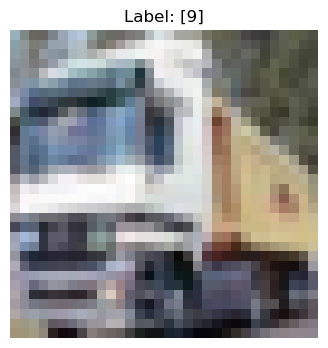

In [10]:
plot_sample(xtrain,ytrain,1)

In [11]:
xtrain = xtrain/255 
xtest = xtest/255

In [14]:
cnn = models.Sequential([
    layers.Conv2D(filters=32,activation='relu',kernel_size = (3,3),input_shape=(32,32,3)),       
    layers.MaxPooling2D((2,2)),       
    layers.Conv2D(filters=64,activation='relu',kernel_size = (3,3),input_shape =(32,32,3)),      
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),       
    layers.Dense(64,activation='relu'),        
    layers.Dense(10,activation='softmax') ]) 
cnn.compile(optimizer='adam',loss='sparse_categorical_crossentropy',
            metrics=['accuracy'])
cnn.fit(xtrain,ytrain,epochs=20)

/home/oem/anaconda3/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1791277602.053991    6218 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Epoch 1/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.4913 - loss: 1.4224
Epoch 2/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.6222 - loss: 1.0783
Epoch 3/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.6669 - loss: 0.9539
Epoch 4/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.6952 - loss: 0.8729
Epoch 5/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.7222 - loss: 0.7989
Epoch 6/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.7419 - loss: 0.7397
Epoch 7/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.7600 - loss: 0.6839
Epoch 8/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.7777 - loss: 0.6377
Epoch 9/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.7886 - loss: 0.5968
Epoch 10/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8065 - loss: 0.5503
Epoch 11/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8193 - loss: 0.5140
Epoch 12/20
1563/1563 ━━━━━━━━

In [15]:
ypred = cnn.predict(xtest)
cnn.evaluate(xtest,ytest)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step  
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6795 - loss: 1.4351  


[1.435144066810608, 0.6794999837875366]

In [16]:
ytest=ytest.reshape(-1,) 
ypred=cnn.predict(xtest) 
yclasses=[np.argmax(element)
          for element in ypred] 
print('classification report:\ n',classification_report(ytest,yclasses))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step 
classification report:\ n               precision    recall  f1-score   support

           0       0.68      0.74      0.71      1000
           1       0.85      0.77      0.81      1000
           2       0.58      0.55      0.57      1000
           3       0.46      0.52      0.49      1000
           4       0.60      0.65      0.63      1000
           5       0.59      0.55      0.57      1000
           6       0.71      0.79      0.75      1000
           7       0.75      0.70      0.72      1000
           8       0.84      0.79      0.81      1000
           9       0.79      0.73      0.76      1000

    accuracy                           0.68     10000
   macro avg       0.69      0.68      0.68     10000
weighted avg       0.69      0.68      0.68     10000

